In [1]:
from pathlib import Path

from config import PLOTS_DIR
from core.sr_study_analysis import run_analysis, run_selected_configs, ExperimentSpec
from core.sr_sim import StudyType

In [2]:
from core.dgp import DGP_EXAMPLES, ARGARCHProcess

DGP_EXAMPLES["ar_garch"]=lambda: ARGARCHProcess()

## Scenarios and parameter grids

In [3]:
# name : (dgp_names, model_short_names)
scenarios = {
    "tails": (
        ["iid_t6"],
        ["iid_normal", "iid_student_t", "iid_nonnormal"],
    ),
    "skew": (
        ["iid_skewt60_m05", "iid_skewt6_m05"],
        ["iid_normal", "iid_student_t", "iid_nonnormal"],
    ),
    "serial": (
        ["ar1_06_normal", "ar1_m06_normal"],
        ["iid_normal", "ar1_normal"],
    ),
    "hetero_tails": (
        ["garch_normal"],
        ["iid_normal", "iid_nonnormal", "garch11"],
    ),
    "serial_hetero": (
        ["ar_garch"],
        ["iid_normal", "iid_nonnormal", "ar1_normal", "ar1_nonnormal", "garch11", "ar1_garch11"],
    ),
}

parameters = {
    "T":     [100, 300, 500, 1_000, 2_000],
}

## Experiment registry

In [4]:
N_SIM  = 50_000
N_JOBS = -1

experiments = {
    "tails": ExperimentSpec(
        scenario   = scenarios["tails"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        sr_default = 0.5,
        th_moments = False,
        n_default  = N_SIM, n_jobs = N_JOBS,
    ),
    "tails_th": ExperimentSpec(
        scenario   = scenarios["tails"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        sr_default = 0.5,
        th_moments = True,
        n_default  = N_SIM, n_jobs = N_JOBS,
    ),
    "skew": ExperimentSpec(
        scenario   = scenarios["skew"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        sr_default = 0.5,
        th_moments = True,
        n_default  = N_SIM, n_jobs = N_JOBS,
    ),
    "serial": ExperimentSpec(
        scenario   = scenarios["serial"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = True,
        n_default  = N_SIM, n_jobs = N_JOBS,
    ),
    "hetero_tails": ExperimentSpec(
        scenario   = scenarios["hetero_tails"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = True,
        n_default  = N_SIM, n_jobs = N_JOBS,
    ),
    "serial_hetero": ExperimentSpec(
        scenario   = scenarios["serial_hetero"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = True,
        n_default  = N_SIM, n_jobs = N_JOBS,
    ),
}

---
## EXECUTION

7.5min

In [5]:
# ── coverage / size runs ──────────────────────────────────────────────────────
run_selected_configs(
    experiments,
    selected_experiments=[
        #"tails",
        #"tails_th",
        #"skew",
        #"serial",
        #"hetero_tails",
        "serial_hetero",
    ],
)


  Experiment: serial_hetero
  [1/5]  T=100  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [2/5]  T=300  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [3/5]  T=500  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [4/5]  T=1000  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [5/5]  T=2000  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE


---
## VISUALIZATION

In [5]:
#common
line_plot_kargs = dict(reverse=False, 
                       linewidth=1,)
folder = PLOTS_DIR / "scenarios"

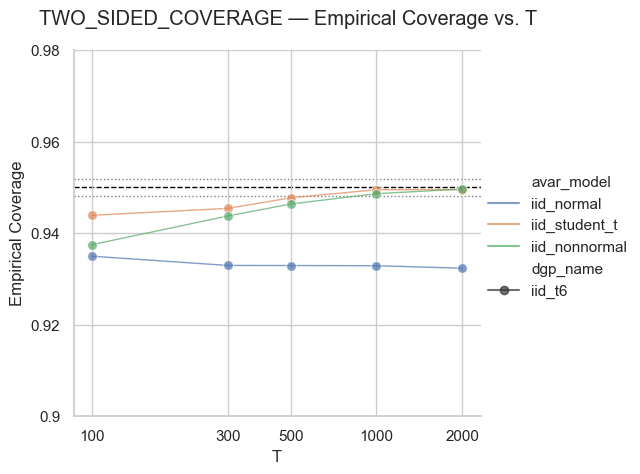

In [28]:
run_analysis(experiments, "tails", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs |
             dict(log=True, yticks=[0.9, 0.92, 0.94, 0.96, 0.98], xticks=parameters['T']))

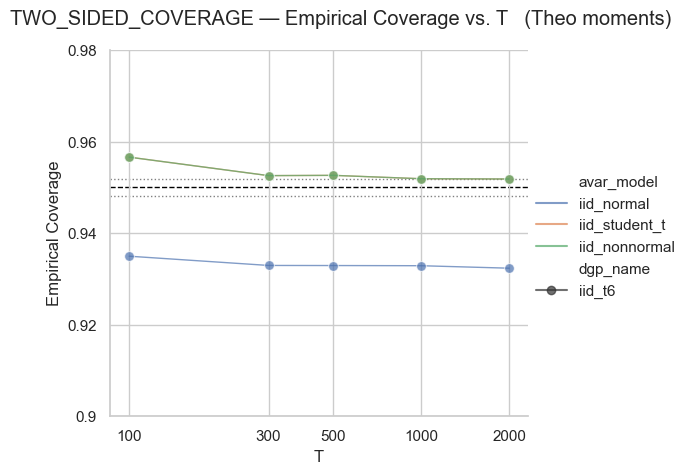

In [29]:
run_analysis(experiments, "tails_th", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, yticks=[0.9, 0.92, 0.94, 0.96, 0.98], xticks=parameters['T']))

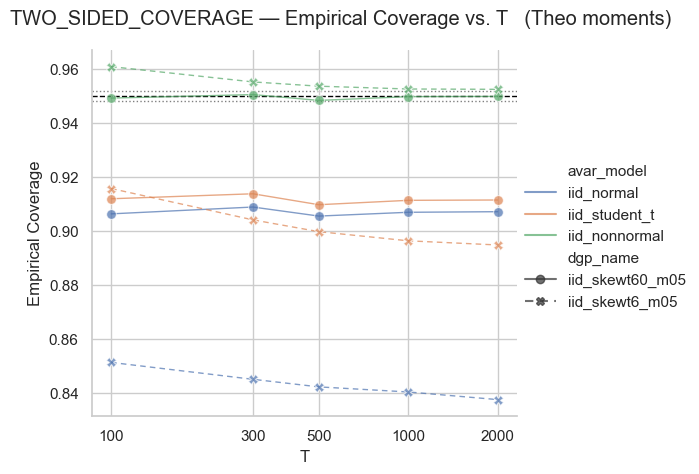

In [30]:
run_analysis(experiments, "skew", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, markers=['o', 'X'], xticks=parameters['T'], dashes=["",(4, 3)]))

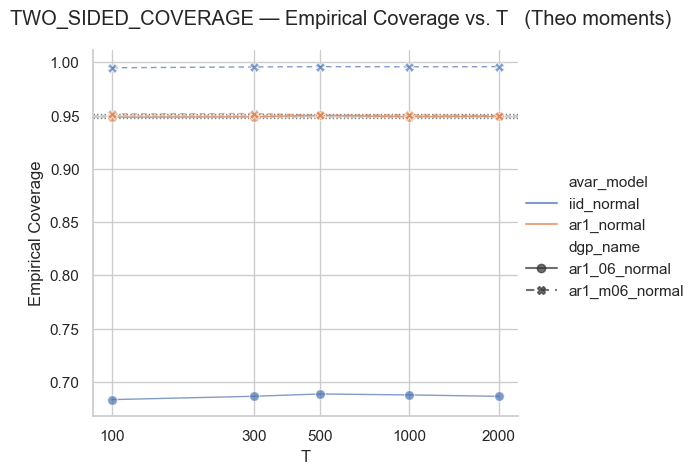

In [6]:
run_analysis(experiments, "serial", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, markers=['o', 'X'], xticks=parameters['T'], dashes=["",(4, 3)]))

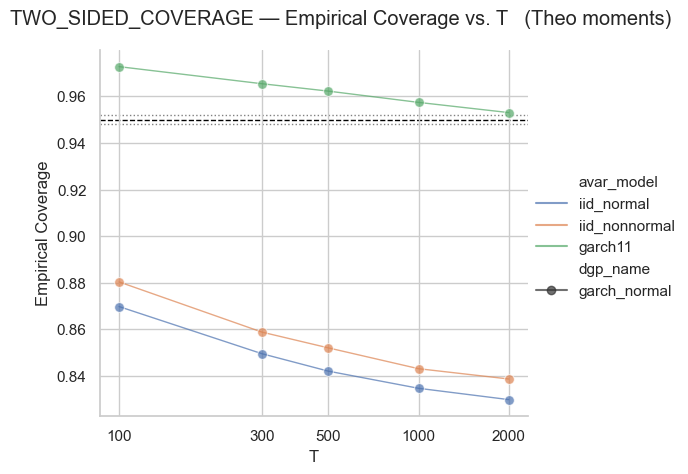

In [32]:
run_analysis(experiments, "hetero_tails", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, xticks=parameters['T']))

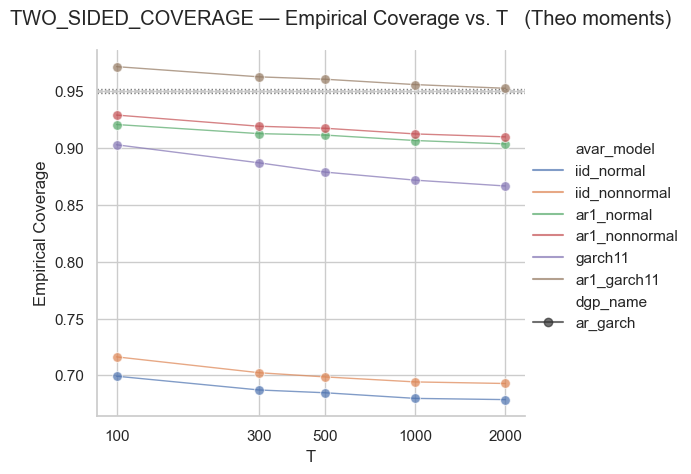

In [7]:
run_analysis(experiments, "serial_hetero", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, xticks=parameters['T']))
